In [87]:
import os
# import globautoriaNumberplateOcrRu-2021-09-01
import math
import random
import json
import glob

import numpy as np
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [88]:
DATASET_ROOT = r"autoriaNumberplateOcrRu"

BATCH_SIZE = 32
IMG_HEIGHT = 32
IMG_WIDTH = 128
MAX_EPOCHS = 50
NUM_WORKERS = 0
RANDOM_SEED = 42

MAX_TRAIN_SAMPLES = 100
MAX_TEST_SAMPLES = 100

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)

In [89]:
ALPHABET = "0123456789ABCDEFGHIJKLMNOPQRSTUVWXYZ"
blank_idx = 0
char2idx = {c: i + 1 for i, c in enumerate(ALPHABET)}
idx2char = {i + 1: c for i, c in enumerate(ALPHABET)}
vocab_size = len(ALPHABET) + 1

train_transforms = T.Compose([
    T.Grayscale(num_output_channels=1),
    T.Resize((IMG_HEIGHT, IMG_WIDTH)),
    T.ToTensor(),
    T.Normalize((0.5,), (0.5,))
])

test_transforms = train_transforms

class NumberplateOCRDataset(Dataset):
    def __init__(self, root, split, transforms=None, max_samples=None):
        self.root = root
        self.split = split
        self.transforms = transforms
        ann_dir = os.path.join(root, split, "ann")
        self.ann_paths = glob.glob(os.path.join(ann_dir, "*.json"))
        self.ann_paths.sort()
        if max_samples is not None:
            self.ann_paths = self.ann_paths[:max_samples]

    def __len__(self):
        return len(self.ann_paths)

    def encode_text(self, text):
        return [char2idx[c] for c in str(text) if c in char2idx]

    def __getitem__(self, idx):
        ann_path = self.ann_paths[idx]
        with open(ann_path, "r", encoding="utf-8") as f:
            data = json.load(f)
        name = data["name"]
        text = str(data.get("description", ""))
        img_rel = os.path.join(self.split, "img", name + ".png")
        img_path = os.path.join(self.root, img_rel)
        image = Image.open(img_path).convert("RGB")
        if self.transforms is not None:
            image = self.transforms(image)
        label = torch.tensor(self.encode_text(text), dtype=torch.long)
        return image, label, text

train_dataset = NumberplateOCRDataset(
    DATASET_ROOT, "train", transforms=train_transforms, max_samples=MAX_TRAIN_SAMPLES
)
test_dataset = NumberplateOCRDataset(
    DATASET_ROOT, "test", transforms=test_transforms, max_samples=MAX_TEST_SAMPLES
)

def collate_fn(batch):
    batch = [b for b in batch if len(b[1]) > 0]
    images = [b[0] for b in batch]
    labels = [b[1] for b in batch]
    texts = [b[2] for b in batch]
    images = torch.stack(images, dim=0)
    label_lengths = torch.tensor([len(l) for l in labels], dtype=torch.long)
    targets = torch.cat(labels, dim=0)
    return images, targets, label_lengths, texts

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    collate_fn=collate_fn,
    drop_last=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    collate_fn=collate_fn,
    drop_last=False
)

In [90]:
def decode_sequence(seq):
    seq = seq.cpu().numpy().tolist()
    prev = None
    out = []
    for s in seq:
        if s != blank_idx and s != prev:
            if s in idx2char:
                out.append(idx2char[s])
        prev = s
    return "".join(out)

def train_epoch(model, loader, optimizer, criterion):
    model.train()
    running_loss = 0.0
    for images, targets, target_lengths, _ in loader:
        images = images.to(device)
        targets = targets.to(device)
        target_lengths = target_lengths.to(device)
        logits = model(images)
        T_cur, N_cur, C_cur = logits.size()
        input_lengths = torch.full(
            size=(N_cur,), fill_value=T_cur, dtype=torch.long, device=logits.device
        )
        loss = criterion(logits, targets, input_lengths, target_lengths)
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
        optimizer.step()
        running_loss += loss.item()
    return running_loss / max(1, len(loader))

def evaluate(model, loader, max_batches=3):
    model.eval()
    samples = []
    with torch.no_grad():
        for bi, (images, targets, target_lengths, texts) in enumerate(loader):
            images = images.to(device)
            logits = model(images)
            pred = logits.permute(1, 0, 2).argmax(2)
            for i in range(images.size(0)):
                decoded = decode_sequence(pred[i])
                gt = texts[i]
                samples.append((gt, decoded))
            if bi + 1 >= max_batches:
                break
    return samples

In [91]:
class SimpleCRNN(nn.Module):
    def __init__(self, vocab_size, img_height=IMG_HEIGHT, img_width=IMG_WIDTH):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2, 2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2, 2),
        )
        # После двух пулингов: 32x128 -> 8x32
        self.rnn = nn.LSTM(64 * 8, 128, batch_first=True, bidirectional=False)
        self.fc = nn.Linear(128, vocab_size)
        
    def forward(self, x):
        x = self.cnn(x)
        x = x.permute(0, 3, 1, 2).reshape(x.size(0), x.size(3), -1)
        x, _ = self.rnn(x)
        return self.fc(x).log_softmax(2).permute(1, 0, 2)

С арихитектурой CRNN во время обучения train loss был всегда nan, поэтому есть версия попроще SimpleCRNN. По количеству параметров в 10 раз меньше получилось.

In [95]:
class CRNN(nn.Module):
    def __init__(self, vocab_size, img_height, img_width):
        super().__init__()

        self.cnn = nn.Sequential(
            # 32x128
            nn.Conv2d(1, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),          # 16x64

            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),          # 8x32

            nn.Conv2d(128, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),

            nn.Conv2d(256, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),

            # уменьшаем только высоту
            nn.MaxPool2d(kernel_size=(2, 1)),   # 4x32

            nn.Conv2d(256, 512, 3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),

            nn.Conv2d(512, 512, 3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),

            # высота станет 2
            nn.MaxPool2d(kernel_size=(2, 1))    # 2x32
        )

        # для IMG_HEIGHT=32
        self.rnn_input_size = 512 * 2

        self.lstm1 = nn.LSTM(
            input_size=self.rnn_input_size,
            hidden_size=256,
            bidirectional=True,
            batch_first=True
        )

        self.lstm2 = nn.LSTM(
            input_size=512,
            hidden_size=256,
            bidirectional=True,
            batch_first=True
        )

        self.fc = nn.Linear(512, vocab_size)

    def forward(self, x):
        x = self.cnn(x)

        # [B,C,H,W] -> [B,W,C*H]
        b, c, h, w = x.size()

        x = x.permute(0, 3, 1, 2)
        x = x.reshape(b, w, c * h)

        x, _ = self.lstm1(x)
        x, _ = self.lstm2(x)

        x = self.fc(x)

        # CTCLoss требует [T,B,C]
        x = x.log_softmax(2)

        return x.permute(1, 0, 2)

In [93]:
class oldCRNN(nn.Module):
    def __init__(self, vocab_size, img_height=IMG_HEIGHT, img_width=IMG_WIDTH):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 64, 3, padding=1)
        self.pool1 = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(64, 128, 3, padding=1)
        self.pool2 = nn.MaxPool2d(2, 2)
        self.conv3 = nn.Conv2d(128, 256, 3, padding=1)
        self.pool3 = nn.MaxPool2d(2, 2)
        
        # Расчет размера после сверток
        cnn_out_height = img_height // 8
        cnn_out_width = img_width // 8
        
        self.rnn_input_size = 256 * cnn_out_height
        self.lstm1 = nn.LSTM(self.rnn_input_size, 256, batch_first=True, bidirectional=True)
        self.lstm2 = nn.LSTM(512, 256, batch_first=True, bidirectional=True)
        self.fc = nn.Linear(512, vocab_size)
        
    def forward(self, x):
        x = torch.relu(self.pool1(self.conv1(x)))
        x = torch.relu(self.pool2(self.conv2(x)))
        x = torch.relu(self.pool3(self.conv3(x)))
        
        # [batch, channels, height, width] -> [batch, width, channels * height]
        batch, c, h, w = x.size()
        x = x.permute(0, 3, 1, 2).reshape(batch, w, c * h)
        
        x, _ = self.lstm1(x)
        x, _ = self.lstm2(x)
        x = self.fc(x)
        
        return x.log_softmax(2).permute(1, 0, 2)  # [T, batch, vocab]

In [96]:
model = CRNN(vocab_size, IMG_HEIGHT, IMG_WIDTH).to(device)
criterion = nn.CTCLoss(blank=blank_idx, zero_infinity=True)
optimizer = optim.Adam(model.parameters(), lr=0.001)

print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")

Model parameters: 8,724,645


In [97]:
for epoch in range(1, MAX_EPOCHS + 1):
    train_loss = train_epoch(model, train_loader, optimizer, criterion)
    print(f"Epoch {epoch}/{MAX_EPOCHS}, train loss: {train_loss:.4f}")

test_samples = evaluate(model, test_loader, max_batches=2)
for i, (gt, pred) in enumerate(test_samples[:20]):
    print(f"{i+1}. GT: {gt} | PRED: {pred}")

Epoch 1/50, train loss: 6.6970
Epoch 2/50, train loss: 3.5499
Epoch 3/50, train loss: 3.2913
Epoch 4/50, train loss: 3.1859
Epoch 5/50, train loss: 3.1186
Epoch 6/50, train loss: 3.0718
Epoch 7/50, train loss: 3.1154
Epoch 8/50, train loss: 3.0701
Epoch 9/50, train loss: 2.9939
Epoch 10/50, train loss: 2.9543
Epoch 11/50, train loss: 2.8867
Epoch 12/50, train loss: 2.8211
Epoch 13/50, train loss: 2.8289
Epoch 14/50, train loss: 2.8425
Epoch 15/50, train loss: 2.7814
Epoch 16/50, train loss: 2.7682
Epoch 17/50, train loss: 2.7092
Epoch 18/50, train loss: 2.6856
Epoch 19/50, train loss: 2.7243
Epoch 20/50, train loss: 2.6524
Epoch 21/50, train loss: 2.6113
Epoch 22/50, train loss: 2.5794
Epoch 23/50, train loss: 2.5216
Epoch 24/50, train loss: 2.5416
Epoch 25/50, train loss: 2.4878
Epoch 26/50, train loss: 2.5227
Epoch 27/50, train loss: 2.5134
Epoch 28/50, train loss: 2.4428
Epoch 29/50, train loss: 2.5318
Epoch 30/50, train loss: 2.3921
Epoch 31/50, train loss: 2.4716
Epoch 32/50, trai

In [100]:
lengths = []

for _, label, text in train_dataset:
    lengths.append(len(label))

print(min(lengths))
print(max(lengths))
print(sum(lengths)/len(lengths))

8
9
8.07


In [ ]:
img, label, text = train_dataset[30]

print(text)
print(img.shape)
print(img.min(), img.max())

B999TC35
torch.Size([1, 32, 128])
tensor(-0.9843) tensor(-0.2157)


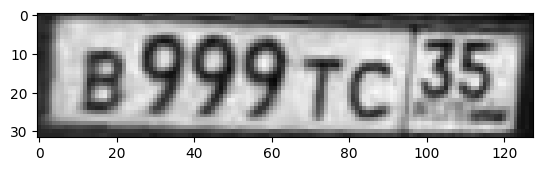

In [ ]:
import matplotlib.pyplot as plt

plt.imshow(img.squeeze(), cmap="gray")
plt.show()

In [98]:
def evaluate_with_metrics(model, loader, max_batches=10, max_print=20):
    model.eval()
    total_seq = 0
    correct_seq = 0
    total_chars = 0
    correct_chars = 0
    samples = []
    with torch.no_grad():
        for bi, (images, targets, target_lengths, texts) in enumerate(loader):
            images = images.to(device)
            logits = model(images)
            pred = logits.permute(1, 0, 2).argmax(2)
            for i in range(images.size(0)):
                decoded = decode_sequence(pred[i])
                gt = str(texts[i])
                samples.append((gt, decoded))
                total_seq += 1
                if decoded == gt:
                    correct_seq += 1
                L = max(len(gt), len(decoded))
                if L > 0:
                    total_chars += L
                    correct_chars += sum(
                        1 for a, b in zip(gt.ljust(L), decoded.ljust(L)) if a == b
                    )
            if bi + 1 >= max_batches:
                break
    seq_acc = correct_seq / max(1, total_seq)
    char_acc = correct_chars / max(1, total_chars)
    print(f"Exact plate accuracy: {seq_acc * 100:.2f}%")
    print(f"Character accuracy:   {char_acc * 100:.2f}%")
    print()
    for i, (gt, pred) in enumerate(samples[:max_print]):
        print(f"{i+1}. GT: {gt} | PRED: {pred}")
    return seq_acc, char_acc, samples

seq_acc, char_acc, test_samples = evaluate_with_metrics(model, test_loader, max_batches=10, max_print=30)

Exact plate accuracy: 0.00%
Character accuracy:   5.23%

1. GT: A001BP54 | PRED: T
2. GT: A001PC71 | PRED: T5
3. GT: A002KX152 | PRED: A35
4. GT: A002XC763 | PRED: A35
5. GT: A002XY89 | PRED: T35
6. GT: A003CX196 | PRED: T35
7. GT: A004OE23 | PRED: A35
8. GT: A005AX26 | PRED: T5
9. GT: A006AA10 | PRED: T
10. GT: A007AE799 | PRED: A35
11. GT: A007CH35 | PRED: A35
12. GT: A007CT163 | PRED: A35
13. GT: A009XX123 | PRED: T5
14. GT: A010TB34 | PRED: T35
15. GT: A011AB39 | PRED: B3535
16. GT: A011YB42 | PRED: A35
17. GT: A012AA05 | PRED: T35
18. GT: A012AH716 | PRED: B35
19. GT: A015YO82 | PRED: A
20. GT: A019AX122 | PRED: A
21. GT: A020AA06 | PRED: T
22. GT: A020AO198 | PRED: B35
23. GT: A020KE123 | PRED: B5
24. GT: A020YK134 | PRED: B35
25. GT: A021HP82 | PRED: B35
26. GT: A021XH86 | PRED: A
27. GT: A025EE73 | PRED: T535
28. GT: A026EY92 | PRED: A
29. GT: A031EK54 | PRED: A35
30. GT: A032AX790 | PRED: T


In [ ]:
from collections import Counter

model.eval()

images, _, _, _ = next(iter(train_loader))

with torch.no_grad():
    logits = model(images.to(device))

pred = logits.argmax(2)  # [T, B]

cnt = Counter(pred.cpu().numpy().flatten())

print(cnt.most_common())

[(np.int64(0), 977), (np.int64(12), 29), (np.int64(6), 15), (np.int64(11), 2), (np.int64(30), 1)]


In [ ]:
# ДИАГНОСТИКА ДАТАСЕТА
ann_sample = glob.glob(os.path.join(DATASET_ROOT, "train", "ann", "*.json"))[0]
img_sample = glob.glob(os.path.join(DATASET_ROOT, "train", "img", "*.png"))[0]

print(f"Пример аннотации: {ann_sample}")
print(f"Пример картинки: {img_sample}")

# Проверяем содержимое JSON
with open(ann_sample, "r", encoding="utf-8") as f:
    data = json.load(f)
    print(f"Содержимое JSON: {data}")
    print(f"Текст номера: {data.get('description')}")

Пример аннотации: autoriaNumberplateOcrRu\train\ann\11_11_2014_10_42_11_230_0.json
Пример картинки: autoriaNumberplateOcrRu\train\img\11_11_2014_10_42_11_230_0.png
Содержимое JSON: {'tags': [], 'objects': [], 'state_id': '2', 'region_id': '6', 'size': {'width': 172, 'height': 37}, 'moderation': {'isModerated': 1}, 'description': 'A088KK60', 'name': '11_11_2014_10_42_11_230_0', 'count_lines': '0'}
Текст номера: A088KK60
